In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#warnings suppress unnecessary warnings 
warnings.filterwarnings('ignore')
#plots appear inside the noteboook
%matplotlib inline

#makes seaborn plots look clean and proffessional
sns.set_style('whitegrid')
sns.set_palette('husl')


In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')


In [3]:
train.head(5)

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [4]:
test.head(5)

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [6]:
# VERY IMPORTANT — this is exactly how our final file must look
# Two columns: Index (from test.csv) and demand (our predictions)

print("=== SAMPLE SUBMISSION ===")
print(sample_sub)

=== SAMPLE SUBMISSION ===
   Index    demand
0      0  0.090768
1      1  0.089885
2      2  0.007037
3      3  0.079087
4      4  0.054636


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41778 entries, 0 to 41777
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          41778 non-null  int64  
 1   geohash        41778 non-null  object 
 2   day            41778 non-null  int64  
 3   timestamp      41778 non-null  object 
 4   RoadType       41454 non-null  object 
 5   NumberofLanes  41778 non-null  int64  
 6   LargeVehicles  41778 non-null  object 
 7   Landmarks      41778 non-null  object 
 8   Temperature    40429 non-null  float64
 9   Weather        41347 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 3.2+ MB


In [9]:
train.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


In [10]:
test.describe()

,Index,day,NumberofLanes,Temperature
count,41778.00000,41778.0,41778.000000,40429.000000
mean,20888.50000,49.0,2.068984,16.457339
std,12060.41411,0.0,0.988519,7.351067
min,0.00000,49.0,1.000000,-21.314645
25%,10444.25000,49.0,1.000000,11.527029
50%,20888.50000,49.0,2.000000,16.471232
75%,31332.75000,49.0,3.000000,21.365883
max,41777.00000,49.0,5.000000,45.230408


In [11]:
train.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [12]:
test.isnull().sum()


Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64

In [23]:
#------------------------MISSING VALUE ANALYSIS---------------------
missing_train =pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isnull().sum() / len(train) * 100).round(2)
})

print(missing_train[missing_train['Missing Count'] > 0])

print("\n=== MISSING VALUES IN TEST ===")
missing_test = pd.DataFrame({
    'Missing Count': test.isnull().sum(),
    'Missing %': (test.isnull().sum() / len(test) * 100).round(2)
})
print(missing_test[missing_test['Missing Count'] > 0])


#this part of the code is used to calculate the missing count and as well as its percentage so that we can calculate the severity as well

             Missing Count  Missing %
RoadType               600       0.78
Temperature           2495       3.23
Weather                797       1.03

=== MISSING VALUES IN TEST ===
             Missing Count  Missing %
RoadType               324       0.78
Temperature           1349       3.23
Weather                431       1.03


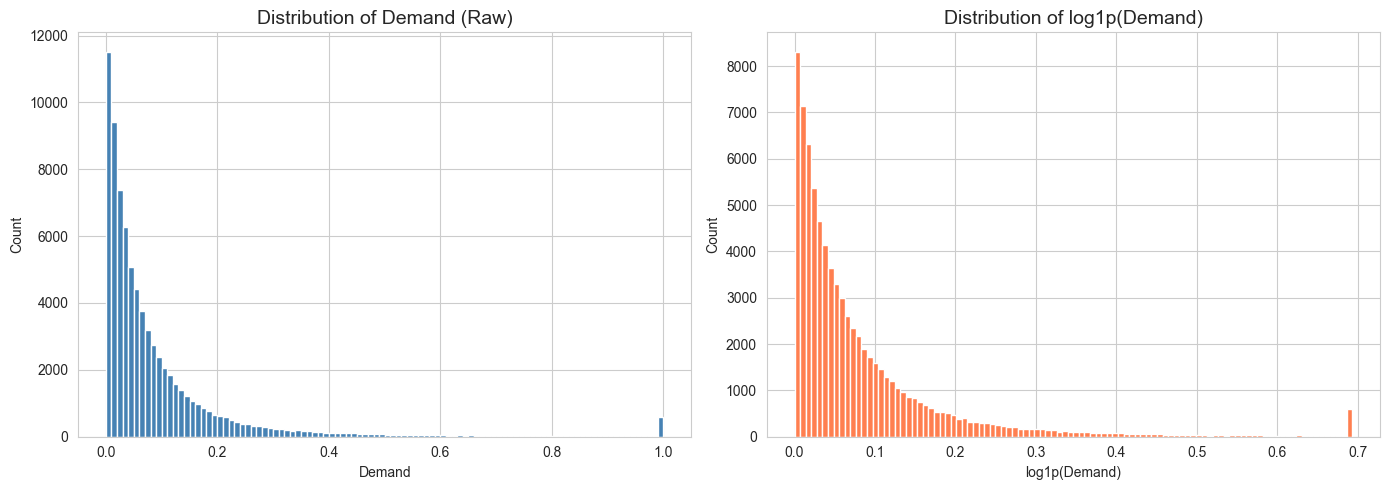


== DEMAND STATISTICS ==
count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


In [15]:
#---------------------------TARGET VARIABLE DISTRIBUTION -------------------------------------
# The target is demand — a float between 0 and 1
# We plot its distribution to understand skewness
# Right-skewed → most locations have LOW demand, a few have VERY HIGH demand

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: raw distribution
axes[0].hist(train['demand'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Demand (Raw)', fontsize=14)
axes[0].set_xlabel('Demand')
axes[0].set_ylabel('Count')

# Right plot: log distribution — helps us see the shape better
axes[1].hist(np.log1p(train['demand']), bins=100, color='coral', edgecolor='white')
axes[1].set_title('Distribution of log1p(Demand)', fontsize=14)
axes[1].set_xlabel('log1p(Demand)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\n== DEMAND STATISTICS ==")
print(train['demand'].describe())

In [16]:
#-------------------------- Unique Values in Each Column--------------------------------------



# Understanding cardinality (number of unique values) for categorical columns
# This tells us which columns need label encoding vs one-hot encoding

categorical_cols = ['geohash', 'RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

print("=== UNIQUE VALUE COUNTS ===")
for col in categorical_cols:
    print(f"\n{col}: {train[col].nunique()} unique values")
    print(train[col].value_counts(dropna=False).head(6))




    

=== UNIQUE VALUE COUNTS ===

geohash: 1249 unique values
geohash
qp03wd    105
qp03wf    105
qp09t0    105
qp03w9    105
qp03x3    105
qp03wc    105
Name: count, dtype: int64

RoadType: 3 unique values
RoadType
Residential    69230
Street          3909
Highway         3560
NaN              600
Name: count, dtype: int64

LargeVehicles: 2 unique values
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

Landmarks: 2 unique values
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64

Weather: 4 unique values
Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
NaN        797
Name: count, dtype: int64


In [ ]:
# geohasH has 1249 unique values------------->labelencoding
# roadtype has 3 unique values-------------->ONE HOT ENCODING
# largeVehciles has 2 unique values---------->ONE HOT ENCODING
# LandMarks has 2 unique values-------------->BINARY OR LABEL ENCODING
# weather has 4 unique values---------------> ONE HOT ENCODING

In [20]:
#------------------------------- Day & Timestamp Analysis-------------------------


print("===DAY DISTRIBUTION===")
print("Train Days:", sorted(train['day'].unique())) #find all distinct days in train dataset
print("Test Days :", sorted(test['day'].unique()))  #find all distinct days in test dataset
print()
print(train['day'].value_counts())   #count value of train dataset

print("===time sample===")
print("Total unique timestamps:", train['timestamp'].nunique())  #count unique timestamp values



===DAY DISTRIBUTION===
Train Days: [np.int64(48), np.int64(49)]
Test Days : [np.int64(49)]

day
48    69427
49     7872
Name: count, dtype: int64
===time sample===
Total unique timestamps: 96


In [21]:
print("Sample timestamps:", sorted(train['timestamp'].unique())[:10])   #shows first 10 of sorted
print("... (96 total = 24 hours × 4 slots per hour = 15-min intervals)") # HERE 96 TIMESTAMPS ARE UIQUE 24 HOURS* 4 INTERVALS/HOURS

Sample timestamps: ['0:0', '0:15', '0:30', '0:45', '10:0', '10:15', '10:30', '10:45', '11:0', '11:15']
... (96 total = 24 hours × 4 slots per hour = 15-min intervals)


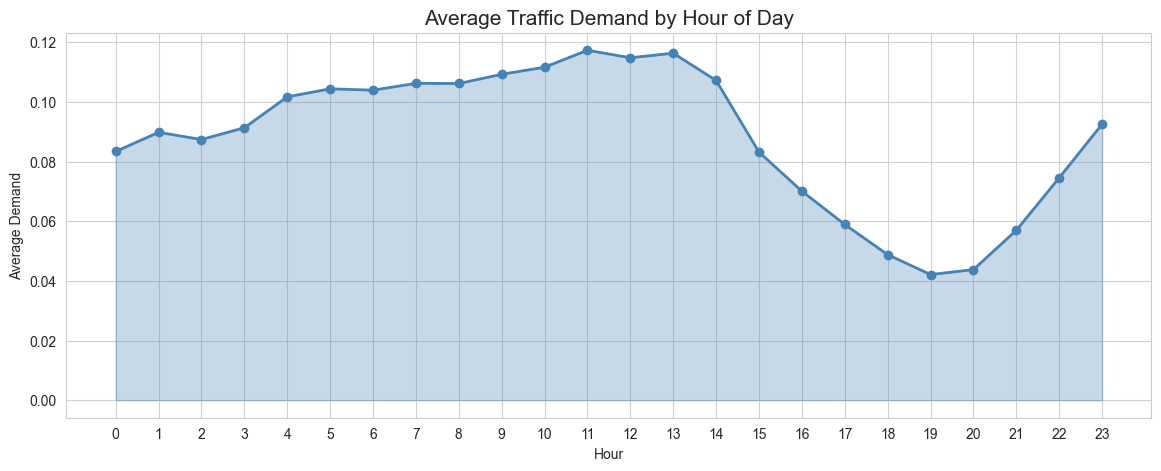

In [25]:
###---------------------Demand by Hour of Day-----------------------


# Extract hour from timestamp to see rush hour patterns
# This is one of the MOST IMPORTANT features

# Parse hour from "H:MM" format
train['hour'] = train['timestamp'].apply(lambda x: int(x.split(':')[0]))   #IT EXTRACTS THE HOUR 

# Average demand per hour
hourly_demand = train.groupby('hour')['demand'].mean().reset_index()   #CALC AVG DEMAND PER HOUR


# PLOT THE FIGURE
plt.figure(figsize=(14, 5))   
plt.plot(hourly_demand['hour'], hourly_demand['demand'], 
         marker='o', color='steelblue', linewidth=2, markersize=6)
plt.fill_between(hourly_demand['hour'], hourly_demand['demand'], alpha=0.3, color='steelblue')
plt.title('Average Traffic Demand by Hour of Day', fontsize=15)
plt.xlabel('Hour')
plt.ylabel('Average Demand')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.9)
plt.show()

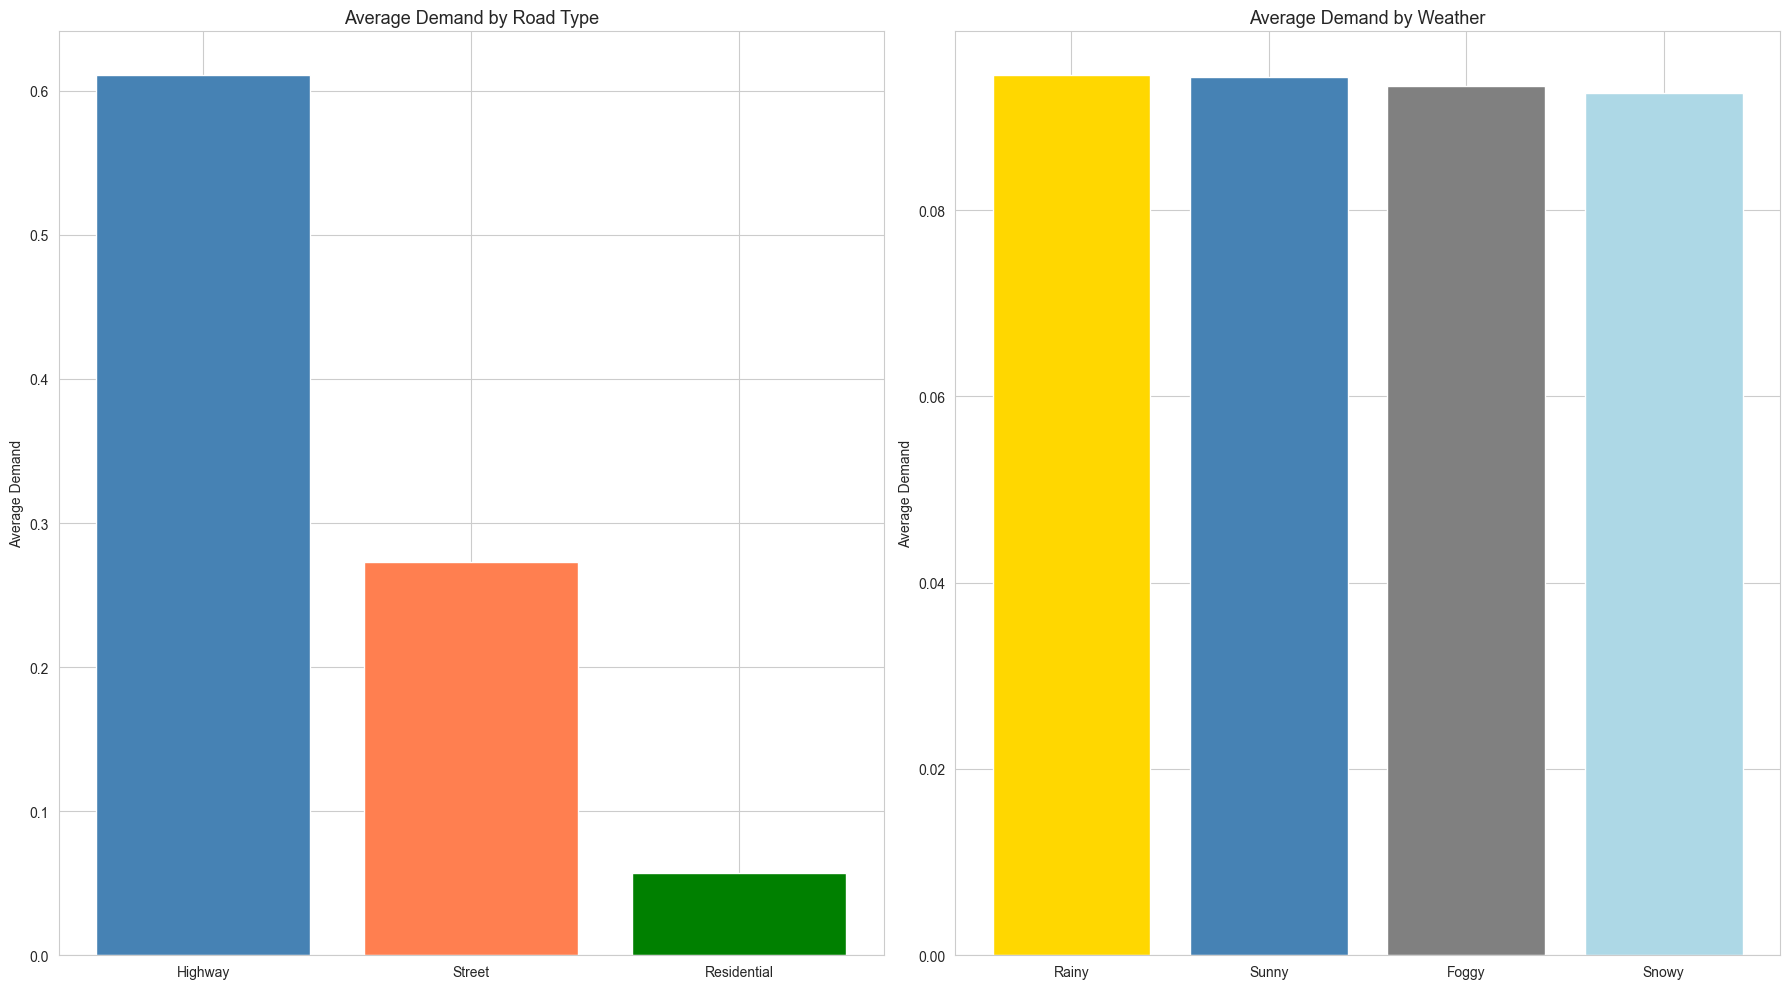

In [35]:
##########------------------Demand by Road Type & Weather-----------------


fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Demand by Road Type
road_demand = train.groupby('RoadType')['demand'].mean().sort_values(ascending=False)
axes[0].bar(road_demand.index, road_demand.values, color=['steelblue','coral','green'])
axes[0].set_title('Average Demand by Road Type', fontsize=13)
axes[0].set_ylabel('Average Demand')

# Demand by Weather
weather_demand = train.groupby('Weather')['demand'].mean().sort_values(ascending=False)
axes[1].bar(weather_demand.index, weather_demand.values, 
            color=['gold','steelblue','gray','lightblue'])
axes[1].set_title('Average Demand by Weather', fontsize=13)
axes[1].set_ylabel('Average Demand')

plt.tight_layout()
plt.show()



In [37]:
#########--------------GEOHASH COVERAGE------------



# Geohash is a location code — like a postal code for GPS coordinates
# Understanding overlap between train and test geohashes is critical

train_geo = set(train['geohash'].unique())
test_geo  = set(test['geohash'].unique())

print(F"Unique geohashes in Train : {len(train_geo)}")
print(f"Unique geohashes in Test  : {len(test_geo)}")
print(f"Geohashes in BOTH         : {len(train_geo & test_geo)}")
print(f"In Test but NOT in Train  : {len(test_geo - train_geo)}")
print()
print(" Only 10 test geohashes are unseen — 99.2% overlap!")
print(" We can safely use geohash-level aggregations as features")

Unique geohashes in Train : 1249
Unique geohashes in Test  : 1190
Geohashes in BOTH         : 1180
In Test but NOT in Train  : 10

 Only 10 test geohashes are unseen — 99.2% overlap!
 We can safely use geohash-level aggregations as features


 Correlation between Day 48 and Day 49 demand: 0.7924
   (For same geohash + timestamp)

Test rows that HAVE a day48 lag: 37136 / 41778
This single feature alone will be incredibly powerful!


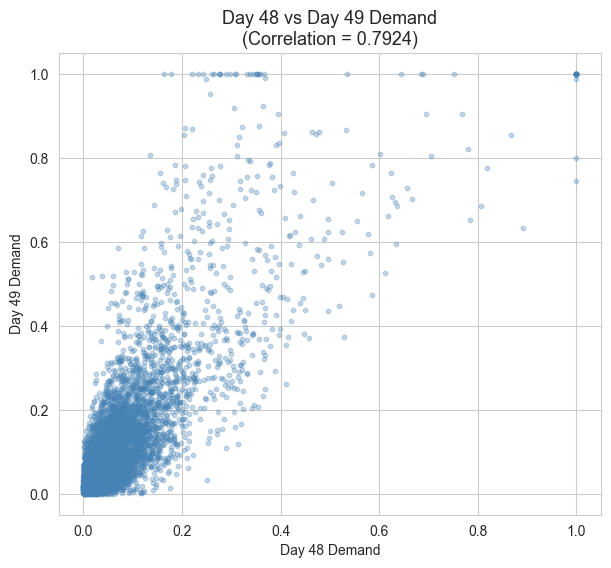

In [38]:

# Since train has day 48 and test is day 49,
# we can use day 48 demand as a "lag feature" to predict day 49 demand


day48 = train[train['day'] == 48][['geohash', 'timestamp', 'demand']].rename(
    columns={'demand': 'lag_demand_day48'}
)
day49_train = train[train['day'] == 49][['geohash', 'timestamp', 'demand']].rename(
    columns={'demand': 'lag_day49'}
)

# Merge day48 and day49 on same geohash+timestamp
overlap = day48.merge(day49_train, on=['geohash', 'timestamp'], how='inner')

# Calculate correlation
corr = overlap['lag_demand_day48'].corr(overlap['lag_day49'])
print(f" Correlation between Day 48 and Day 49 demand: {corr:.4f}")
print(f"   (For same geohash + timestamp)")
print()
print(f"Test rows that HAVE a day48 lag: {len(day48.merge(test, on=['geohash','timestamp'], how='inner'))} / {len(test)}")
print("This single feature alone will be incredibly powerful!")

# Visualize
plt.figure(figsize=(7,6))
plt.scatter(overlap['lag_demand_day48'], overlap['lag_day49'], 
            alpha=0.3, s=10, color='steelblue')
plt.xlabel('Day 48 Demand')
plt.ylabel('Day 49 Demand')
plt.title(f'Day 48 vs Day 49 Demand\n(Correlation = {corr:.4f})', fontsize=13)
plt.show()